# 04 - Literature Calibration: Lidocaine Permeation

This notebook validates the V2 layered model by calibrating to published
lidocaine hydrochloride permeation targets through human skin.

**Reference:** Adamiak-Giera et al. (2023), *Frontiers in Pharmacology*,
doi:10.3389/fphar.2023.1157977

| Quantity | Literature value | Unit |
|----------|----------------:|------|
| Permeability $K_P$ | $7.38 \times 10^{-7}$ | cm/s |
| Lag time $T_{\text{lag}}$ | 1.401 | hours |

The paper reports macroscopic $K_P$ and $T_{\text{lag}}$ from Franz-cell measurements.
Layer-specific diffusivities $D_i$ are not reported, so we use inverse calibration:
tune layered $D$ values until simulated $P$ and $T_{\text{lag}}$ match literature targets.

This is a validation/calibration notebook (V2), not the final surrogate-training regime
used for report results (which is V3 clearance-aware).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})
print('Repo root:', repo_root)

Repo root: /run/media/sc23n2w/DATA/COMP3931_IndividualProject


## 1 - Run calibrated simulation

The config `v2_lidocaine_compare.yaml` encodes:
- Total skin thickness ~ 0.512 mm (matching the paper's 0.5 mm)
- Layer thicknesses: SC (1 row ~ 8 µm), VE (9 rows ~ 72 µm), dermis (54 rows ~ 432 µm)
- Calibrated $D$ values (Nelder-Mead inverse fit): $[5.55 \times 10^{-10},\; 1.513 \times 10^{-8},\; 2.701 \times 10^{-7}]$ cm²/s

In [2]:
import contextlib
import io

cfg = load_config('configs/sim/v2_lidocaine_compare.yaml')
with contextlib.redirect_stderr(io.StringIO()):
    C_snap, t_save, D_field, k_field, patch_mask, diagnostics, metrics, stability_info = run_simulation(cfg)

# Literature targets
lit = cfg.extras.get('literature', {})
P_target = lit['P_target_cm_s']
Tlag_target_h = lit['Tlag_target_hours']

# Simulated outputs
P_sim = metrics.get('P')
Tlag_raw = metrics.get('Tlag')
Tlag_sim_h = Tlag_raw / 3600.0 if Tlag_raw is not None else None

P_err  = 100.0 * (P_sim / P_target - 1.0)
T_err  = 100.0 * (Tlag_sim_h / Tlag_target_h - 1.0) if Tlag_sim_h is not None else float('nan')

print(f'P_sim    = {P_sim:.4e} cm/s   (target {P_target:.4e})   error {P_err:+.3f} %')
print(f'Tlag_sim = {Tlag_sim_h:.4f} h        (target {Tlag_target_h:.3f})       error {T_err:+.3f} %')

P_sim    = 7.3798e-07 cm/s   (target 7.3800e-07)   error -0.003 %
Tlag_sim = 1.4018 h        (target 1.401)       error +0.056 %


**Breakdown.**

- This step runs the literature-anchored V2 configuration once and extracts the two key calibration outputs: permeability ($P$) and lag time ($T_{lag}$).
- Literature targets are loaded directly from the config metadata, so the comparison is traceable and reproducible.
- The reported percentage errors are the core calibration check before moving to curve and field interpretation.


## 2 - Flux curve $J(t)$

The classic infinite-dose flux profile: an initial lag followed by rise to steady state.

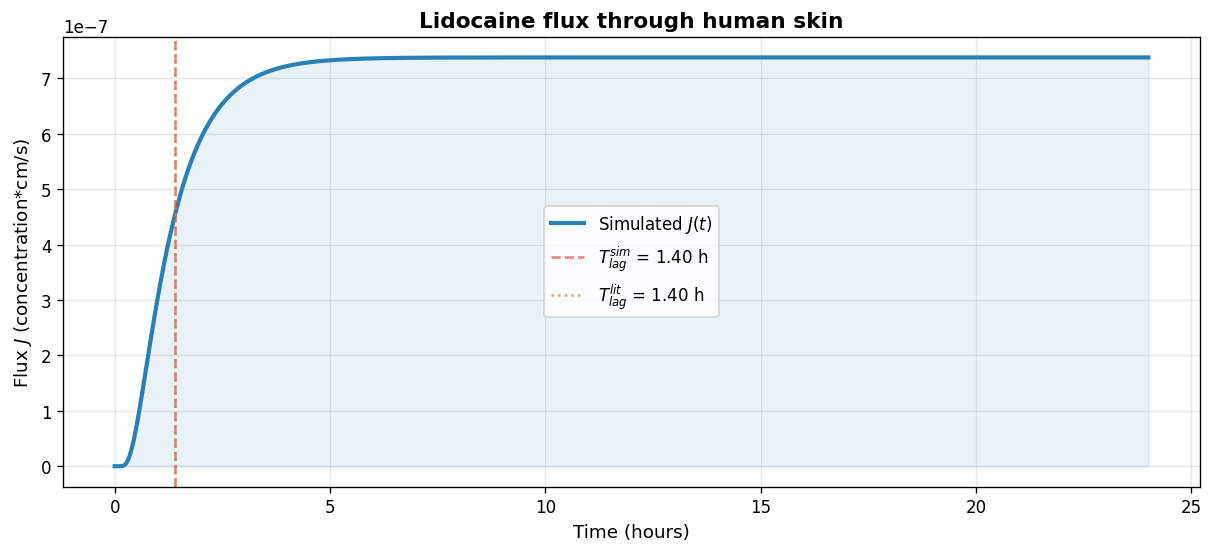

In [3]:
J = np.array(metrics['J'], dtype=float)
t_hours = np.array(metrics['t'], dtype=float) / 3600.0

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.plot(t_hours, J, lw=2.5, color='#2980b9', label='Simulated $J(t)$')
ax.fill_between(t_hours, 0, J, alpha=0.1, color='#2980b9')

# Mark lag time
if Tlag_sim_h is not None:
    ax.axvline(Tlag_sim_h, ls='--', color='#e74c3c', alpha=0.7, label=f'$T_{{lag}}^{{sim}}$ = {Tlag_sim_h:.2f} h')
ax.axvline(Tlag_target_h, ls=':', color='#e67e22', alpha=0.7, label=f'$T_{{lag}}^{{lit}}$ = {Tlag_target_h:.2f} h')

ax.set_title('Lidocaine flux through human skin', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flux $J$ (concentration*cm/s)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

**Lidocaine flux curve $J(t)$ over 24 hours.**

- The curve shows the expected infinite-dose profile: lag period, then rise toward a near-steady plateau.
- Vertical markers compare simulated and literature lag time directly.
- Use the printed values from the code cell for exact current calibration errors (kept dynamic/reproducible).

## 3 - Permeability & lag time comparison

Side-by-side bars comparing simulated vs literature values.

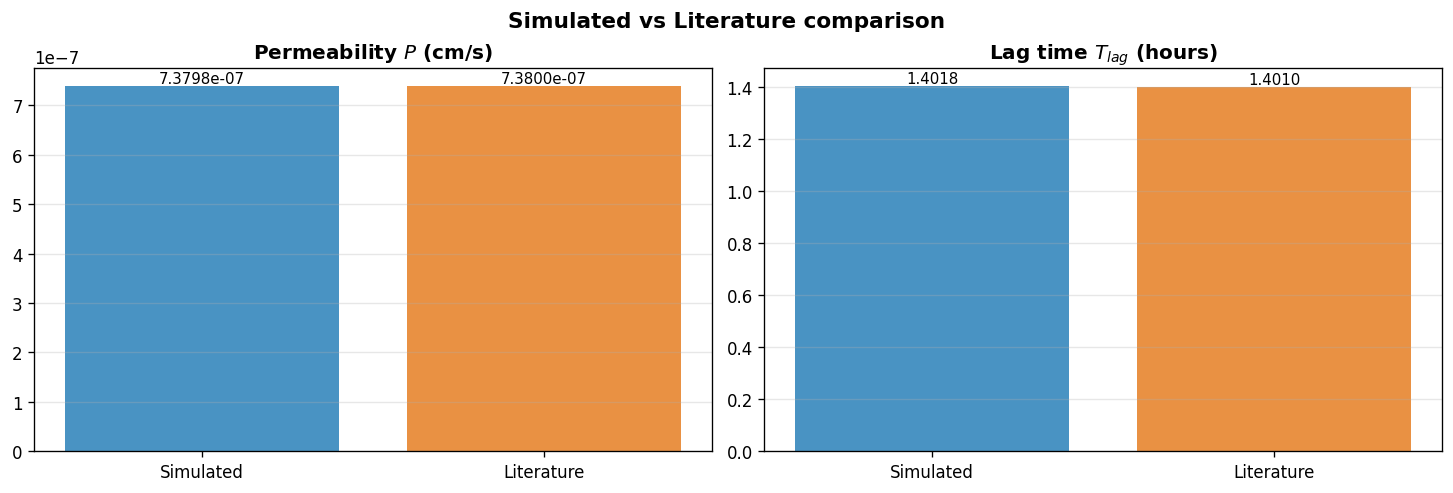

Drug       : Lidocaine hydrochloride (P-KET/LH/EtOH)
P error    : -0.0032 %
Tlag error : +0.0560 %


In [4]:
# --- Permeability & lag time side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig.suptitle('Simulated vs Literature comparison', fontsize=13, fontweight='bold')

# Permeability
bars = ax1.bar(
    ['Simulated', 'Literature'],
    [P_sim, P_target],
    color=['#2980b9', '#e67e22'],
    alpha=0.85,
)
ax1.set_title('Permeability $P$ (cm/s)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [P_sim, P_target]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, val,
        f'{val:.4e}', ha='center', va='bottom', fontsize=9,
    )

# Lag time
vals_t = [Tlag_sim_h if Tlag_sim_h is not None else 0.0, Tlag_target_h]
bars = ax2.bar(
    ['Simulated', 'Literature'],
    vals_t,
    color=['#2980b9', '#e67e22'],
    alpha=0.85,
)
ax2.set_title('Lag time $T_{lag}$ (hours)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vals_t):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, val,
        f'{val:.4f}', ha='center', va='bottom', fontsize=9,
    )

plt.show()

# --- Error summary ---
P_err_bar  = 100.0 * (P_sim / P_target - 1.0) if P_target else float('nan')
T_err_bar  = 100.0 * (Tlag_sim_h / Tlag_target_h - 1.0) if (Tlag_sim_h is not None and Tlag_target_h) else float('nan')
print(f'Drug       : {lit.get("drug", "--")}')
print(f'P error    : {P_err_bar:+.4f} %')
print(f'Tlag error : {T_err_bar:+.4f} %')

**Permeability and lag-time comparison.**

- Left bar chart: simulated vs literature permeability $P$.
- Right bar chart: simulated vs literature lag time $T_{\text{lag}}$.
- Use the printed error summary above for exact values; this keeps the notebook robust to reruns or small calibration updates.